# Clase 3 – Random Forest

## Objetivo
Construir y evaluar un modelo robusto.

In [49]:
#Archivo: Dataset_agro_rd_validado.csv
#Contexto: Produccion agricola en la republica dominicana
#Objetivo: Predecir la produccion agricola basada en diferentes factores
import pandas as pd

#cargar los datos
df = pd.read_csv('dataset_agro_rd_validado.csv')

#vista de los datos
df.head()

,Año,Mes,Región,Clima,Producto,Preparación_Suelo,Área_Sembrada_Tareas,Unidad_Medida,Producción_Total,Precio_Unitario
0,2021,4,Sur,Semiárido,Tayota,Invernadero,53,Unidades,241805.97,35.28
1,2024,2,Este,Tropical de Sabana,Tomate de Ensalada,Invernadero,312,Libras,468588.22,34.46
2,2023,11,Este,Tropical de Sabana,Cebolla Roja,Corte y Quema,75,Quintales (QQ),811.44,2653.71
3,2024,11,Este,Tropical de Sabana,Ñame,Arado Mecanizado,174,Quintales (QQ),573.60,2672.60
4,2020,7,Norte,Templado,Tayota,Invernadero,110,Unidades,265287.76,49.53


In [50]:
# Nivel de producción
df['nivel_produccion'] = pd.qcut(
df['Producción_Total'], q=3, labels=['Baja', 'Media', 'Alta']
)


# Rentabilidad
df['ingreso_total'] = df['Producción_Total'] * df['Precio_Unitario']
df['rentabilidad'] = pd.qcut(
df['ingreso_total'], q=3, labels=['Baja', 'Media', 'Alta']
)

In [51]:
#valiacion de la creacion de nuevas columnas
df.head()

,Año,Mes,Región,Clima,Producto,Preparación_Suelo,Área_Sembrada_Tareas,Unidad_Medida,Producción_Total,Precio_Unitario,nivel_produccion,ingreso_total,rentabilidad
0,2021,4,Sur,Semiárido,Tayota,Invernadero,53,Unidades,241805.97,35.28,Alta,8.530915e+06,Alta
1,2024,2,Este,Tropical de Sabana,Tomate de Ensalada,Invernadero,312,Libras,468588.22,34.46,Alta,1.614755e+07,Alta
2,2023,11,Este,Tropical de Sabana,Cebolla Roja,Corte y Quema,75,Quintales (QQ),811.44,2653.71,Baja,2.153326e+06,Media
3,2024,11,Este,Tropical de Sabana,Ñame,Arado Mecanizado,174,Quintales (QQ),573.60,2672.60,Baja,1.533003e+06,Media
4,2020,7,Norte,Templado,Tayota,Invernadero,110,Unidades,265287.76,49.53,Alta,1.313970e+07,Alta


In [52]:
#creacion de caracteristicas en el DF

caracteristicas = ['Área_Sembrada_Tareas','Producción_Total','Precio_Unitario','Mes']

X = df[caracteristicas]
y = df['nivel_produccion']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df['rentabilidad'], test_size=0.2, random_state=42)

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred_rf = rf.predict(X_test)
print('Prediccion del modelo Random Forest:',y_test, y_pred_rf)

Prediccion del modelo Random Forest: 47044     Alta
44295     Baja
74783     Baja
70975     Alta
46645    Media
         ...  
67666    Media
51146     Alta
42494     Baja
52517    Media
7754      Baja
Name: rentabilidad, Length: 16000, dtype: category
Categories (3, object): ['Baja' < 'Media' < 'Alta'] ['Alta' 'Baja' 'Baja' ... 'Media' 'Media' 'Baja']


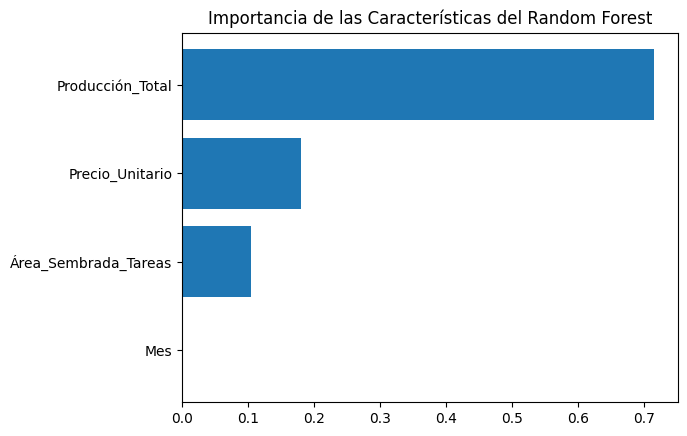

In [57]:
import matplotlib.pyplot as plt
import numpy as np

importancias = rf.feature_importances_
indices = np.argsort(importancias)

plt.title('Importancia de las Características del Random Forest')
plt.barh(range(len(indices)), importancias[indices])
plt.yticks(range(len(indices)), [caracteristicas[i] for i in indices])
plt.show()


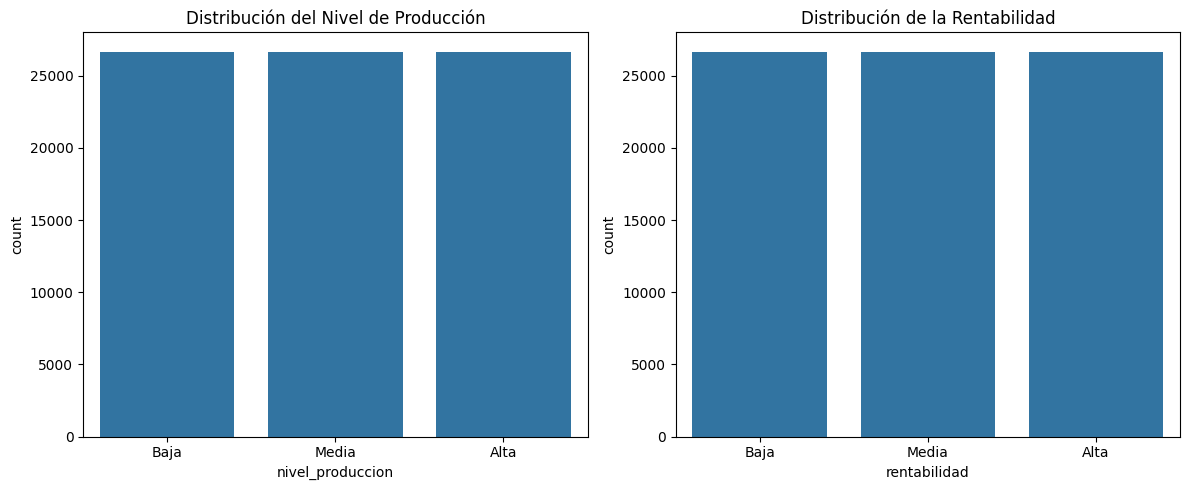

In [58]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='nivel_produccion', data=df, ax=axes[0])
axes[0].set_title('Distribución del Nivel de Producción')

sns.countplot(x='rentabilidad', data=df, ax=axes[1])
axes[1].set_title('Distribución de la Rentabilidad')

plt.tight_layout()
plt.show()

In [59]:
from sklearn.metrics import classification_report
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        Alta       0.94      0.91      0.93      5283
        Baja       0.98      0.92      0.95      5279
       Media       0.86      0.93      0.89      5438

    accuracy                           0.92     16000
   macro avg       0.93      0.92      0.92     16000
weighted avg       0.93      0.92      0.92     16000

